# 04 - Inferential Statistics: t-test, ANOVA, Correlation


## 1) Learning Objectives

- Explain hypothesis-testing workflow.
- Interpret p-values correctly.
- Compute and explain correlation.
- Apply t-test (2 groups) and ANOVA (3 groups).


## 2) Why This Topic Matters

Descriptive statistics summarize what we observed.
Inferential statistics helps answer:

- Is this pattern likely real?
- Could this difference happen by chance?


## 3) Short and Simple Theory Explanation

- **Null hypothesis (H0)**: no effect or no difference.
- **Alternative hypothesis (H1)**: effect or difference exists.
- **p-value**: how surprising data are if H0 were true.
- **t-test**: compare two group means.
- **ANOVA**: compare means across 3+ groups.


## 4) Step-by-Step Code Examples

### Step 4.1 - Import tools

**What are we trying to learn?**  
Set up tests and visualization in a reproducible way.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind, f_oneway
from sklearn.datasets import load_iris
import pandas as pd

np.random.seed(42)
sns.set_theme(style="whitegrid")


**Interpretation**

Environment is ready for both synthetic and real-data demonstrations.


### Step 4.2 - Synthetic two-group example (old notebook teaching flow)

**What are we doing?**  
Create two groups with different means.

**What should we expect?**  
Distributions overlap but group B center is slightly higher.


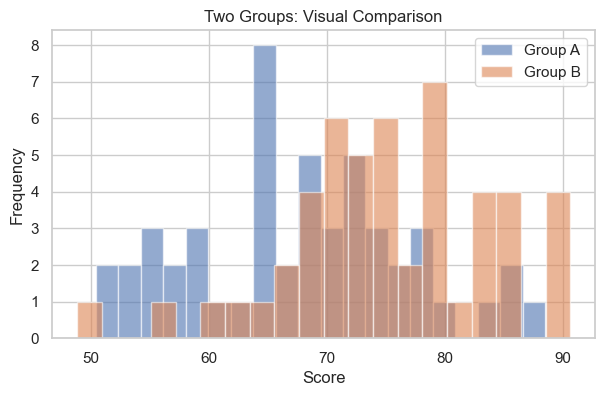

In [2]:
# Simulate two groups with different average values
group_A = np.random.normal(loc=70, scale=10, size=50)
group_B = np.random.normal(loc=75, scale=10, size=50)

# Visual comparison
plt.figure(figsize=(7, 4))
plt.hist(group_A, bins=20, alpha=0.6, label="Group A")
plt.hist(group_B, bins=20, alpha=0.6, label="Group B")
plt.xlabel("Score")
plt.ylabel("Frequency")
plt.title("Two Groups: Visual Comparison")
plt.legend()
plt.show()


**Interpretation**

Visual overlap does not mean groups are equal. We still need a statistical test.

**Why this matters**

Humans are often poor at judging significance from plots alone.


### Step 4.3 - t-test on synthetic groups

**What should students notice?**  
p-value tells us whether observed difference is unlikely under H0.


In [3]:
# Independent t-test
t_stat, p_value = ttest_ind(group_A, group_B)
print("t-statistic:", t_stat)
print("p-value:", p_value)

alpha = 0.05
if p_value < alpha:
    print("Decision: Reject H0 (means differ).")
else:
    print("Decision: Fail to reject H0.")


t-statistic: -4.108723928204809
p-value: 8.261945608702615e-05
Decision: Reject H0 (means differ).


**Interpretation**

If p-value is below 0.05, evidence supports a mean difference.

**Common mistake**

Thinking p-value is probability that H0 is true.


### Step 4.4 - Extend to three groups and ANOVA

**What are we doing?**  
Add a third group and test all means together.


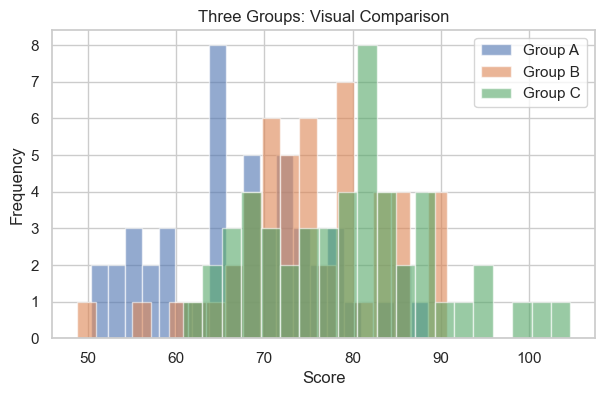

F-statistic: 20.204864820562076
p-value: 1.7684885161380812e-08
Decision: Reject H0 (at least one mean differs).


In [4]:
# Add third group
group_C = np.random.normal(loc=80, scale=10, size=50)

# Visualize all three groups
plt.figure(figsize=(7, 4))
plt.hist(group_A, bins=20, alpha=0.6, label="Group A")
plt.hist(group_B, bins=20, alpha=0.6, label="Group B")
plt.hist(group_C, bins=20, alpha=0.6, label="Group C")
plt.xlabel("Score")
plt.ylabel("Frequency")
plt.title("Three Groups: Visual Comparison")
plt.legend()
plt.show()

# One-way ANOVA
f_stat, p_anova = f_oneway(group_A, group_B, group_C)
print("F-statistic:", f_stat)
print("p-value:", p_anova)

if p_anova < alpha:
    print("Decision: Reject H0 (at least one mean differs).")
else:
    print("Decision: Fail to reject H0.")


**Interpretation**

ANOVA answers if any group differs, not which pair differs.

**Why this matters**

Use post-hoc tests after significant ANOVA for pairwise details.


### Step 4.5 - Correlation on Iris dataset

**What are we trying to learn?**  
How numeric features move together in a real dataset.


In [5]:
# Load Iris and prepare frame
iris = load_iris(as_frame=True)
df = iris.frame.copy()
df["species"] = df["target"].map(dict(enumerate(iris.target_names)))
df = df.drop(columns=["target"])

# Correlation matrix on numeric columns
corr_matrix = df.select_dtypes(include="number").corr()
print(corr_matrix)


                   sepal length (cm)  sepal width (cm)  petal length (cm)  \
sepal length (cm)           1.000000         -0.117570           0.871754   
sepal width (cm)           -0.117570          1.000000          -0.428440   
petal length (cm)           0.871754         -0.428440           1.000000   
petal width (cm)            0.817941         -0.366126           0.962865   

                   petal width (cm)  
sepal length (cm)          0.817941  
sepal width (cm)          -0.366126  
petal length (cm)          0.962865  
petal width (cm)           1.000000  


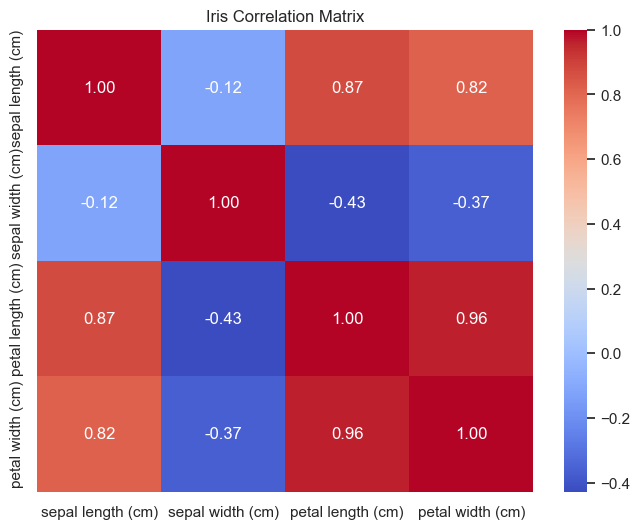

In [6]:
# Heatmap to interpret relationships quickly
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Iris Correlation Matrix")
plt.show()


**Interpretation**

- Strong positive values indicate features increase together.
- Correlation is association, not causation.

**Common mistake**

Treating high correlation as proof of causal effect.


### Step 4.6 - t-test and ANOVA on Iris (applied link)

**What should we expect?**  
Species means often differ for petal measures.


In [7]:
# t-test: setosa vs versicolor sepal length
setosa_sl = df[df["species"] == "setosa"]["sepal length (cm)"]
versicolor_sl = df[df["species"] == "versicolor"]["sepal length (cm)"]

t_stat_iris, p_t_iris = ttest_ind(setosa_sl, versicolor_sl, equal_var=False)
print("Iris t-test p-value:", p_t_iris)

# ANOVA: petal length across three species
g1 = df[df["species"] == "setosa"]["petal length (cm)"]
g2 = df[df["species"] == "versicolor"]["petal length (cm)"]
g3 = df[df["species"] == "virginica"]["petal length (cm)"]

f_iris, p_a_iris = f_oneway(g1, g2, g3)
print("Iris ANOVA p-value:", p_a_iris)


Iris t-test p-value: 3.746742613983842e-17
Iris ANOVA p-value: 2.8567766109615584e-91


**Interpretation**

This connects synthetic intuition to real data inference.


## 8) Small Concept Check Questions (with answers)

**Q1:** What does a small p-value indicate?  
**A1:** Data are unlikely under H0, so we have evidence against H0.

**Q2:** What is the difference between t-test and ANOVA?  
**A2:** t-test compares two means; ANOVA compares three or more means.


## 9) Key Takeaways

- Hypothesis testing needs a clear H0/H1 statement.
- p-values are evidence measures, not truth probabilities.
- Correlation supports association analysis, not causal claims.
- Use t-test for 2 groups and ANOVA for 3+ groups.


## 10) Optional Short Practice / Challenge

Run pairwise t-tests among all Iris species for petal length and compare with the ANOVA conclusion.
